<h1>📊 Final Year Project (PFE) – Exploratory Data Analysis (Part 2)</h1>
<h2>Financial Analysis and Forecasting for an Engineering Consulting Firm</h2>

<hr>

<h3>⚙️ Project Overview</h3>
<p>
This notebook covers the <strong>in-depth analysis and insights extraction</strong> phase of the cleaned sales dataset (2023–2025) from <em>an anonymized company</em>. 
The goal is to uncover sales patterns, client behavior, and financial KPIs to support <strong>predictive modeling</strong> and <strong>business intelligence dashboards</strong>.
</p>

<hr>

<h3>🎯 Objectives</h3>
<ul>
  <li>Perform exploratory analysis to identify sales trends and seasonality</li>
  <li>Analyze client behavior and segmentation</li>
  <li>Investigate key financial metrics</li>
</ul>

<hr>

<h3>📌 Data Sources</h3>
<ul>
  <li> Cleaned sales records </li>
</ul>

<hr>

<h3>🗂️ Notebook Summary</h3>
<p>This notebook focuses on exploring and visualizing the cleaned sales dataset. Main steps include:</p>
<ul>
  <li><strong>1. Load Cleaned Data:</strong> Import libraries and load the dataset into a DataFrame.</li>
  <li><strong>2. General Sales Analysis:</strong> Descriptive statistics, distributions, and outlier detection.</li>
  <li><strong>3. Sales Patterns & Trends:</strong> Time-series analysis of gross/net sales and profit, seasonality checks.</li>
  <li><strong>4. Client Analysis & Segmentation:</strong> Compare sales, discounts, and profit by client category.</li>
  <li><strong>5. Financial KPIs:</strong> Explore profit, margin and discount rate.</li>
  <li><strong>6. Visualizations:</strong> Generate heatmaps for insights.</li>
</ul>

<hr>

<strong>👨‍💻 Author:</strong> 
<a href="https://linkedin.com/in/asma-bouach">Asma Bouach</a><br>
<strong>📅 Project Period:</strong> Feb-May 2025<br>
<strong>🎓 Thesis Defense:</strong> July 2025<br>
<strong>🔄 Last Updated:</strong> November 2025 (Refactored with synthetic sata)
</p>

### 1. Load Cleaned Data

In [1]:
# 📦 Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# 🧹 Suppress warnings
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [2]:
# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

##### 1.1 Loading the data

In [3]:
df = pd.read_parquet('../data/processed/data_cleaned.parquet')

##### 1.2 Initial data inspection

In [4]:
print("=== Data Shape ===")
print(f"Dataset Shape: {df.shape}")

=== Data Shape ===
Dataset Shape: (26507, 15)


In [6]:
display(df.head())

,Client_ID,Invoice_Number,Date,Gross_Sales,Discount,Net_Sales,CoG,Profit,VAT,Stamp_Duty,Total_Amount,Client_Category,Payment_Method,Is_Return,Client_Type
0,C812,OR2300000003,2023-01-01,2015.65,0.00,2015.65,1670.28,345.37,382.97,1.00,2399.62,Private Organization,Cash,No,OR
1,C2773,OR2300000004,2023-01-01,1531.69,0.00,1531.69,976.30,555.39,291.02,1.00,1823.71,Private Organization,Cash,No,OR
2,C2264,OR2300000005,2023-01-01,1746.59,0.00,1746.59,1084.43,662.16,331.85,1.00,2079.44,Private Organization,Cash,No,OR
3,C2404,OR2300000001,2023-01-01,19066.38,0.00,19066.38,8251.99,10814.39,3622.61,1.00,22689.99,Private Organization,Cash,No,OR
4,C2592,OR2300000002,2023-01-01,14487.86,0.00,14487.86,8670.07,5817.79,2752.69,1.00,17241.55,Private Organization,Cash,No,OR


In [7]:
#Convert 'Date' column to datetime if it's not already
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

In [8]:
print("=== Data Types ===")
print(df.info())

=== Data Types ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26507 entries, 0 to 26506
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Client_ID        26507 non-null  object        
 1   Invoice_Number   26507 non-null  object        
 2   Date             26507 non-null  datetime64[ns]
 3   Gross_Sales      26507 non-null  float64       
 4   Discount         26507 non-null  float64       
 5   Net_Sales        26507 non-null  float64       
 6   CoG              26507 non-null  float64       
 7   Profit           26507 non-null  float64       
 8   VAT              26507 non-null  float64       
 9   Stamp_Duty       26507 non-null  float64       
 10  Total_Amount     26507 non-null  float64       
 11  Client_Category  26507 non-null  object        
 12  Payment_Method   26507 non-null  object        
 13  Is_Return        26507 non-null  object        
 14  Client_Type      26

In [9]:
print(f"Date range: {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Total rows: {df.shape[0]}")
print("Unique clients:", df['Client_ID'].nunique())
df.describe()
df.isna().sum()

Date range: 2023-01-01 → 2025-11-23
Total rows: 26507
Unique clients: 2804


Client_ID          0
Invoice_Number     0
Date               0
Gross_Sales        0
Discount           0
Net_Sales          0
CoG                0
Profit             0
VAT                0
Stamp_Duty         0
Total_Amount       0
Client_Category    0
Payment_Method     0
Is_Return          0
Client_Type        0
dtype: int64

##### 1.3 Create time-based features

In [10]:
# Create derived columns for analysis
df['Year'] = df['Date'].dt.year
df['Quarter'] = df['Date'].dt.quarter
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
# 'Weekday' column (Day of the week, 0 = Monday, 6 = Sunday)
df['Weekday'] = df['Date'].dt.weekday
df.head()

,Client_ID,Invoice_Number,Date,Gross_Sales,Discount,Net_Sales,CoG,Profit,VAT,Stamp_Duty,Total_Amount,Client_Category,Payment_Method,Is_Return,Client_Type,Year,Quarter,Month,Day,Weekday
0,C812,OR2300000003,2023-01-01,2015.65,0.00,2015.65,1670.28,345.37,382.97,1.00,2399.62,Private Organization,Cash,No,OR,2023,1,1,1,6
1,C2773,OR2300000004,2023-01-01,1531.69,0.00,1531.69,976.30,555.39,291.02,1.00,1823.71,Private Organization,Cash,No,OR,2023,1,1,1,6
2,C2264,OR2300000005,2023-01-01,1746.59,0.00,1746.59,1084.43,662.16,331.85,1.00,2079.44,Private Organization,Cash,No,OR,2023,1,1,1,6
3,C2404,OR2300000001,2023-01-01,19066.38,0.00,19066.38,8251.99,10814.39,3622.61,1.00,22689.99,Private Organization,Cash,No,OR,2023,1,1,1,6
4,C2592,OR2300000002,2023-01-01,14487.86,0.00,14487.86,8670.07,5817.79,2752.69,1.00,17241.55,Private Organization,Cash,No,OR,2023,1,1,1,6


In [11]:
print("=== Column Names ===")
print(df.columns.tolist())

=== Column Names ===
['Client_ID', 'Invoice_Number', 'Date', 'Gross_Sales', 'Discount', 'Net_Sales', 'CoG', 'Profit', 'VAT', 'Stamp_Duty', 'Total_Amount', 'Client_Category', 'Payment_Method', 'Is_Return', 'Client_Type', 'Year', 'Quarter', 'Month', 'Day', 'Weekday']


<br>
<hr>
<h4>📝 Dataset Overview </h4>

Below is a general overview of the cleaned dataset, including the number of rows and columns, along with a short description of each feature:

<p style="font-weight:bold">🧾 General Info</p>

- **Number of rows:** 26507
- **Number of columns:** 20
- **Time Range Covered:** 2023–2025 (35 months)
- **Client Types Covered:** State, Insurance, Large Accounts, Individual Customers


<p style="font-weight:bold">
📑 Column Description</p> 
<table border="1" cellpadding="5" cellspacing="0">
  <thead> 
    <tr> 
      <th>Column Name</th> 
      <th>Description</th> 
      <th>Data Type</th> 
    </tr> 
  </thead> 
  <tbody> 
    <tr><td><code>Client_ID</code></td><td>Unique identifier for each client</td><td>object</td></tr> 
    <tr><td><code>Invoice_Number</code></td><td>Unique invoice reference</td><td>object</td></tr> 
    <tr><td><code>Date</code></td><td>Date of the transaction</td><td>datetime64[ns]</td></tr> 
    <tr><td><code>Gross_Sales</code></td><td>Total sales before any discounts</td><td>float64</td></tr> 
    <tr><td><code>Discount</code></td><td>Total discount amount applied</td><td>float64</td></tr> 
    <tr><td><code>Net_Sales</code></td><td>Sales amount after applying discounts</td><td>float64</td></tr> 
    <tr><td><code>CoG</code></td><td>Cost of goods sold</td><td>float64</td></tr> 
    <tr><td><code>Profit</code></td><td>Net_Sales minus CoG</td><td>float64</td></tr> 
    <tr><td><code>VAT</code></td><td>Value-added tax applied to the sale</td><td>float64</td></tr> 
    <tr><td><code>Stamp_Duty</code></td><td>Stamp duty tax applied</td><td>float64</td></tr> 
    <tr><td><code>Total_Amount</code></td><td>Final total amount (Net Sales + Taxes)</td><td>float64</td></tr> 
    <tr><td><code>Client_Type</code></td><td>Type of client (State, Insurance, etc.)</td><td>object</td></tr> 
    <tr><td><code>Year</code></td><td>Year of transaction (extracted from Date)</td><td>int32</td></tr> 
    <tr><td><code>Quarter</code></td><td>Quarter of the year (1-4) based on the Date</td><td>int32</td></tr> 
    <tr><td><code>Month</code></td><td>Month of transaction (extracted from Date)</td><td>int32</td></tr> 
    <tr><td><code>Day</code></td><td>Day of the month (from Date)</td><td>int32</td></tr> 
    <tr><td><code>Weekday</code></td><td>Day of the week (0 = Monday)</td><td>int32</td></tr> 
    <tr><td><code>Payment_Method</code></td><td>Method of payment used in the transaction</td><td>object</td></tr> 
    <tr><td><code>Is_Return</code></td><td>Indicates if the transaction is a return (Yes/No)</td><td>object</td></tr> 
    <tr><td><code>Client_Category</code></td><td>Client grouping based on business rules (State, Insurance, Large Accounts, Individual Customers)</td><td>object</td></tr>
  </tbody> 
</table>
<hr>

### 2. Descriptive Statistics

In [12]:
df.describe()

,Date,Gross_Sales,Discount,Net_Sales,CoG,Profit,VAT,Stamp_Duty,Total_Amount,Year,Quarter,Month,Day,Weekday
count,26507,26507.00,26507.00,26507.00,26507.00,26507.00,26507.00,26507.00,26507.00,26507.00,26507.00,26507.00,26507.00,26507.00
mean,2024-06-12 03:04:48.874636800,9238.58,4.69,9223.42,4321.13,4938.81,1752.45,0.83,10976.70,2023.95,2.48,6.43,15.68,2.47
min,2023-01-01 00:00:00,-5439.41,0.00,-5439.41,0.00,0.00,-1033.48,0.00,-6472.90,2023.00,1.00,1.00,1.00,0.00
25%,2023-09-26 00:00:00,402.26,0.00,402.06,156.86,203.24,76.40,1.00,479.08,2023.00,1.00,3.00,9.00,1.00
50%,2024-06-14 00:00:00,1817.45,0.00,1816.30,779.49,926.08,345.10,1.00,2162.40,2024.00,2.00,6.00,16.00,2.00
75%,2025-03-04 00:00:00,7042.03,0.00,7036.44,3194.99,3600.22,1336.92,1.00,8374.37,2025.00,3.00,9.00,23.00,4.00
max,2025-11-23 00:00:00,166120.85,241.16,165685.15,79796.08,90325.84,31480.18,1.00,197166.33,2025.00,4.00,12.00,31.00,6.00
std,NaN,23354.57,28.63,23304.36,11042.15,12573.92,4427.83,0.38,27732.22,0.81,1.12,3.42,8.52,1.79


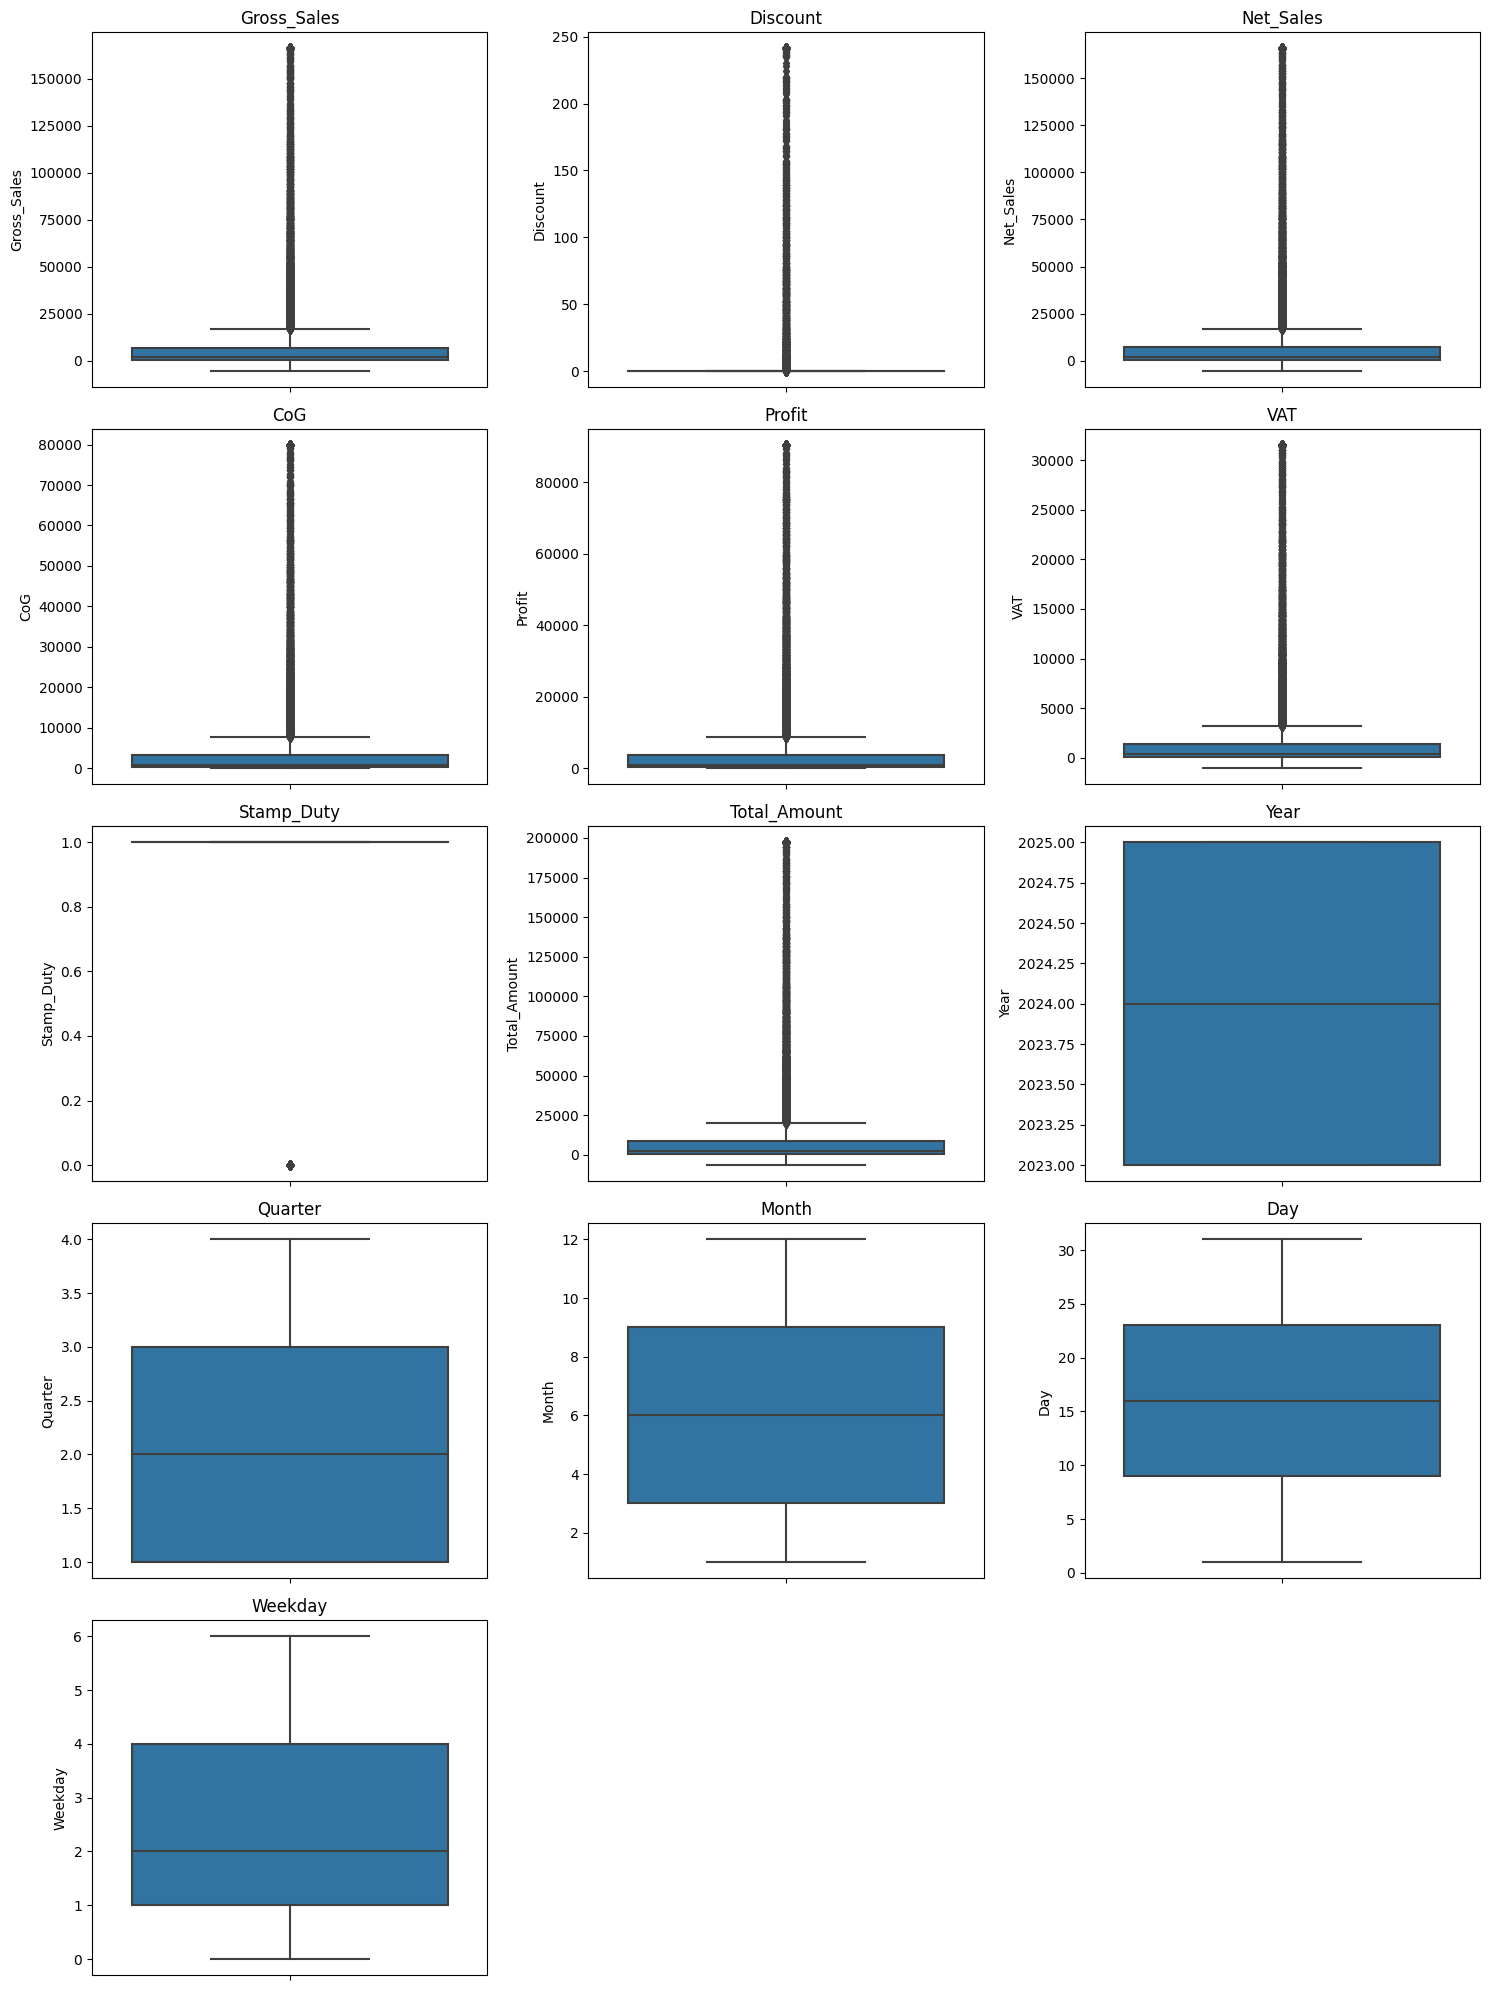

In [13]:
#function to plot boxplots for all numerical columns 
def plot_boxplots_separately(df):
    numeric_cols = df.select_dtypes(include='number').columns
    n_cols = 3  # number of subplots per row
    n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = axes.flatten()
    
    for i, col in enumerate(numeric_cols):
        sns.boxplot(y=df[col], ax=axes[i])
        axes[i].set_title(col)
    
    # Remove empty subplots
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()

plot_boxplots_separately(df)

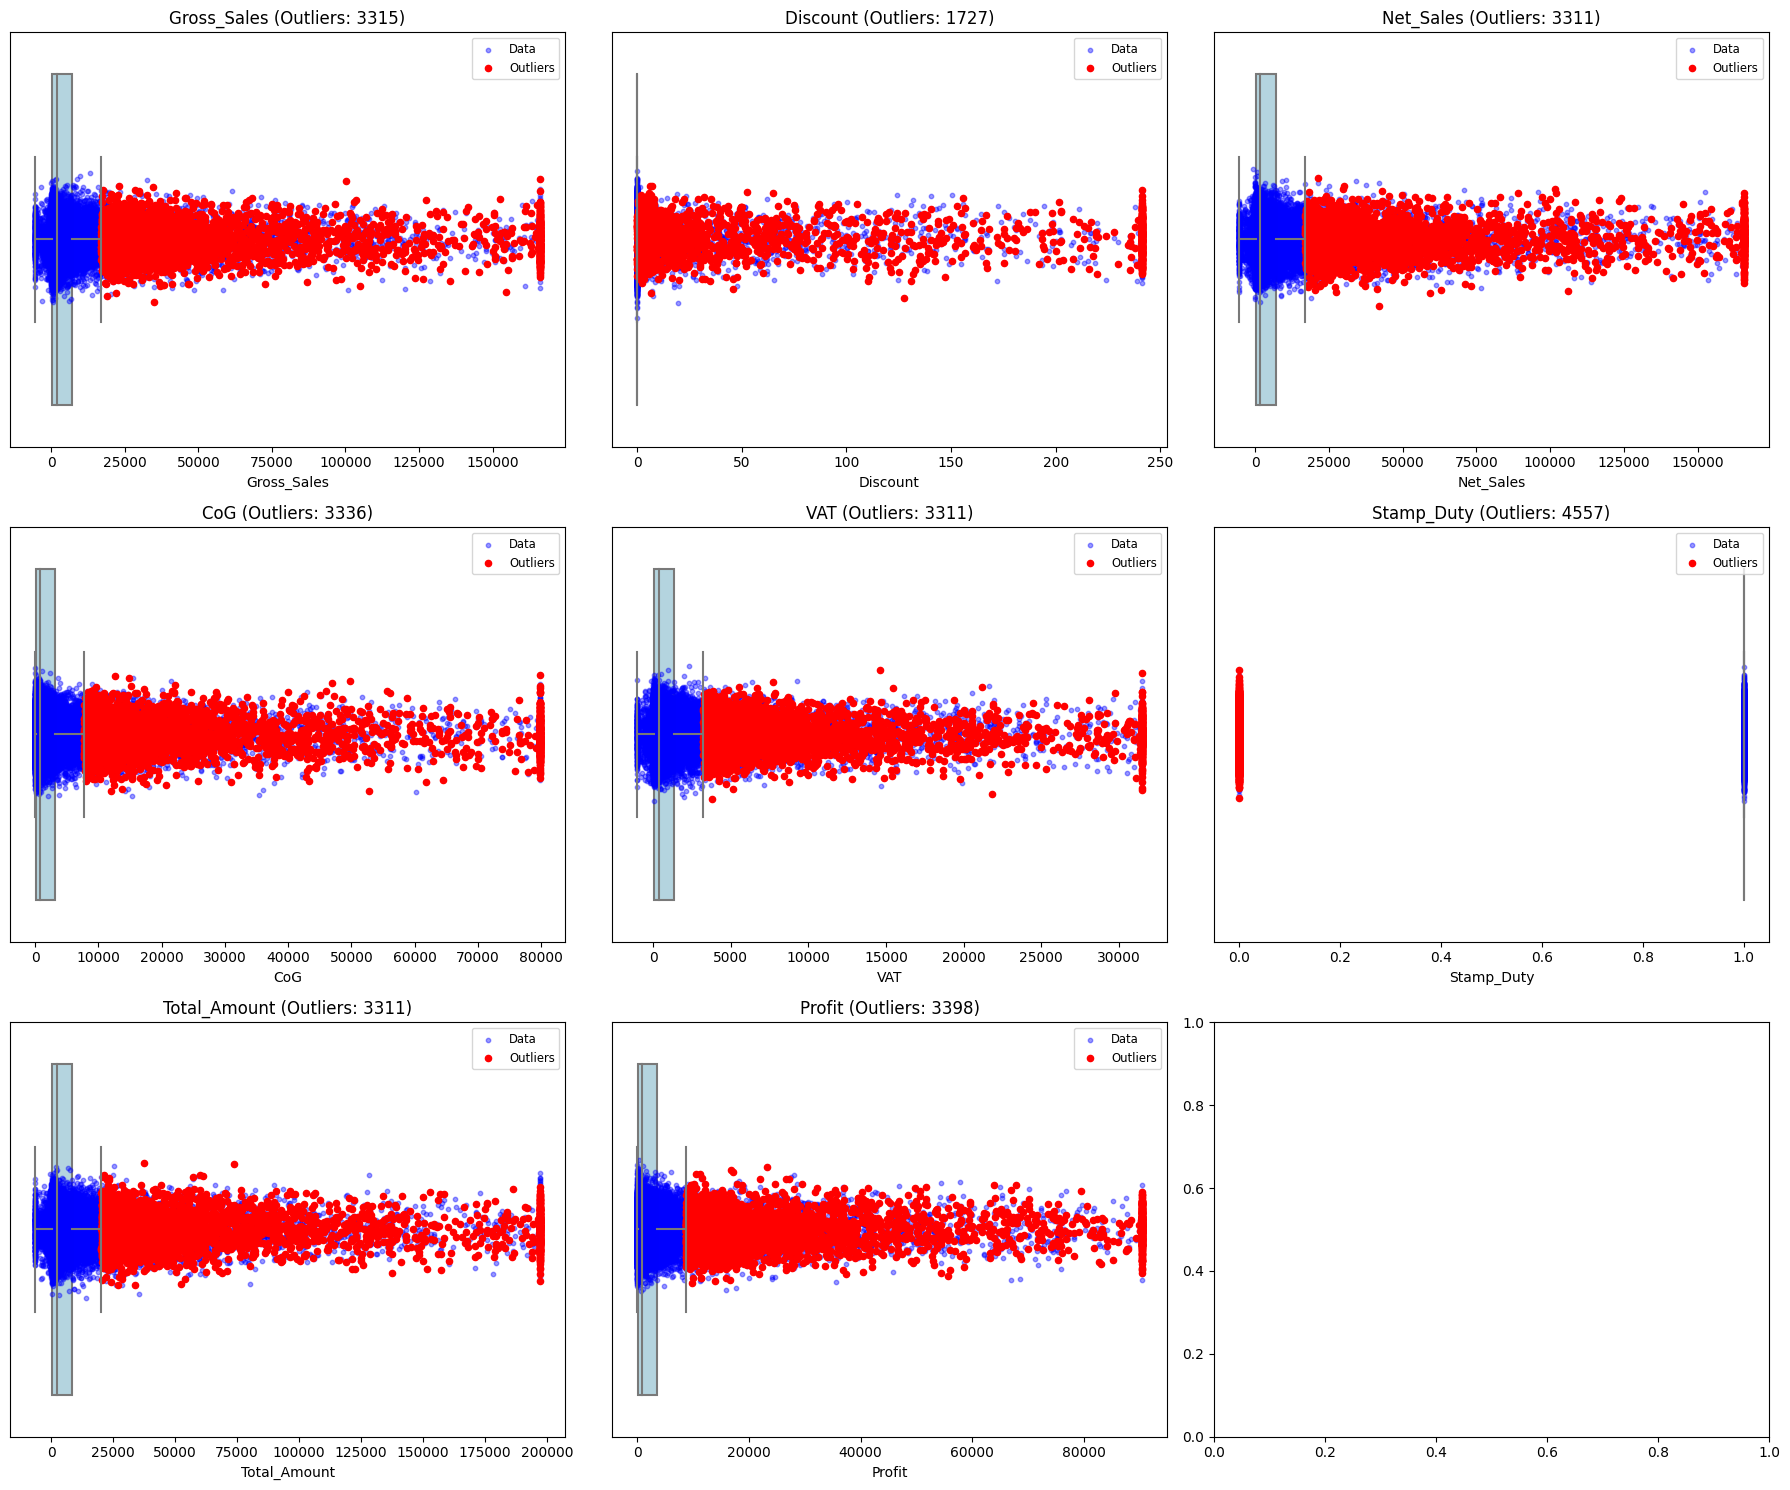

In [14]:
# Detect outliers using the IQR method and visualizes them with combined boxplots and scatter plots for multiple numeric columns.
def detect_outliers_mask(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (df[column] < lower_bound) | (df[column] > upper_bound)

# Set up the plot grid size (3 rows x 3 cols for 9 columns)
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()
num_cols = ['Gross_Sales', 'Discount', 'Net_Sales', 'CoG', 'VAT', 'Stamp_Duty', 'Total_Amount', 'Profit']
for i, col in enumerate(num_cols):
    ax = axes[i]
    
    # Detect outliers mask
    outlier_mask = detect_outliers_mask(df, col)
    
    # Boxplot
    sns.boxplot(x=df[col], ax=ax, color='lightblue', fliersize=0)  # fliersize=0 hides default outliers
    
    # Scatter plot of all points (jitter y to avoid overlap)
    y_all = np.random.normal(0, 0.04, size=len(df))  # jitter y around 0 for scatter
    ax.scatter(df[col], y_all, alpha=0.4, color='blue', s=10, label='Data')
    
    # Scatter plot of outliers in red
    y_outliers = np.random.normal(0, 0.04, size=outlier_mask.sum())
    ax.scatter(df.loc[outlier_mask, col], y_outliers, color='red', s=20, label='Outliers')
    
    ax.set_yticks([])  # Hide y-axis ticks because y is jitter only
    ax.set_title(f'{col} (Outliers: {outlier_mask.sum()})')
    ax.legend(loc='upper right', fontsize='small')

plt.tight_layout()
plt.show()

In [15]:
print("=== Overall Sales Statistics ===")

total_sales =  df['Total_Amount'].sum() - df.loc[df['Client_Type'] == 'AV', 'Total_Amount'].sum()
#total_sales = df.loc[df['Client_Type'] != 'AV', 'Total_Amount'].sum()
avg_transaction = df['Total_Amount'].mean()
total_profit = df['Profit'].sum()
overall_margin = (total_profit / df['Net_Sales'].sum()) * 100

print(f"Total Sales (Net TTC): {total_sales:,.2f}")
print(f"Average Transaction Value: {avg_transaction:,.2f}")
print(f"Total Profit: {total_profit:,.2f}")
print(f"Overall Profit Margin: {overall_margin:.2f}%")

=== Overall Sales Statistics ===
Total Sales (Net TTC): 290,959,288.70
Average Transaction Value: 10,976.70
Total Profit: 130,913,044.39
Overall Profit Margin: 53.55%


<br>
<hr>
<h4>📝 Descriptive Statistics Summary</h4>

<ul>
  <li><strong>Total sales (Net TTC):</strong> 290,959,288.70 TND with an average transaction value of <strong>10,976.70 TND</strong></li>
  <li><strong>Total Profit:</strong> 130,913,044.39 TND</li>
  <li><strong>Overall Profit Margin:</strong> 53.55%</li>
</ul>

<p><strong>Outlier detection</strong> through boxplots revealed that over 3,000~3,400 records are considered extreme for <em>Total_Amount</em>, <em>Gross_Sales</em>, and <em>Profit</em>. These outliers are preserved as they reflect the natural variability and real-world financial behavior, even though this is a synthetic dataset mimicking actual business transactions.</p>
<hr>

### 3. Sales Patterns & Trends

C:\Users\Schnell\AppData\Local\Temp\ipykernel_16744\657927563.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df.set_index('Date').resample('M').agg({


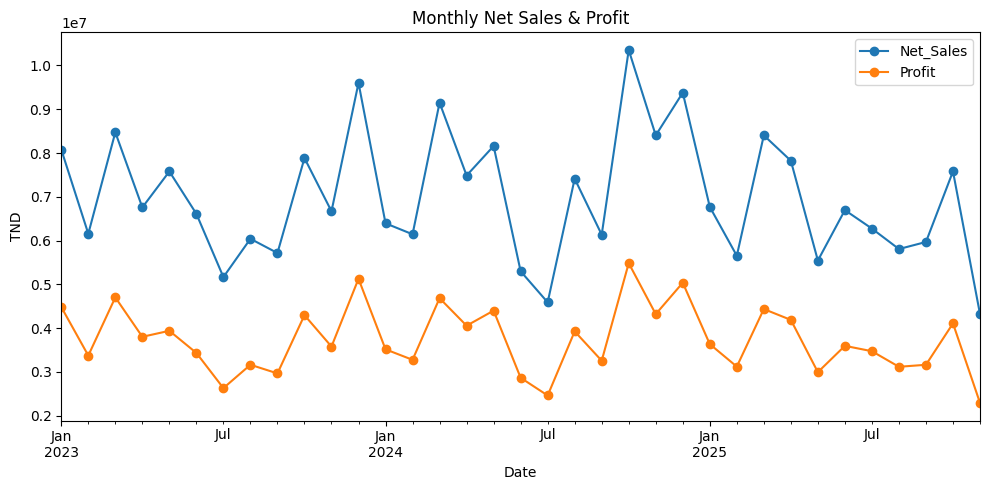

In [16]:
# Resample the data by month, aggregating total Net Sales and total Profit per month

monthly = df.set_index('Date').resample('M').agg({
    'Net_Sales': 'sum',
    'Profit': 'sum'
})
# Plot monthly total Net Sales and Profit to analyze financial trends over time
# This helps visualize revenue and profitability evolution across months
monthly.plot(title='Monthly Net Sales & Profit', figsize=(10, 5), marker='o')
plt.ylabel('TND')
plt.tight_layout()
plt.show()

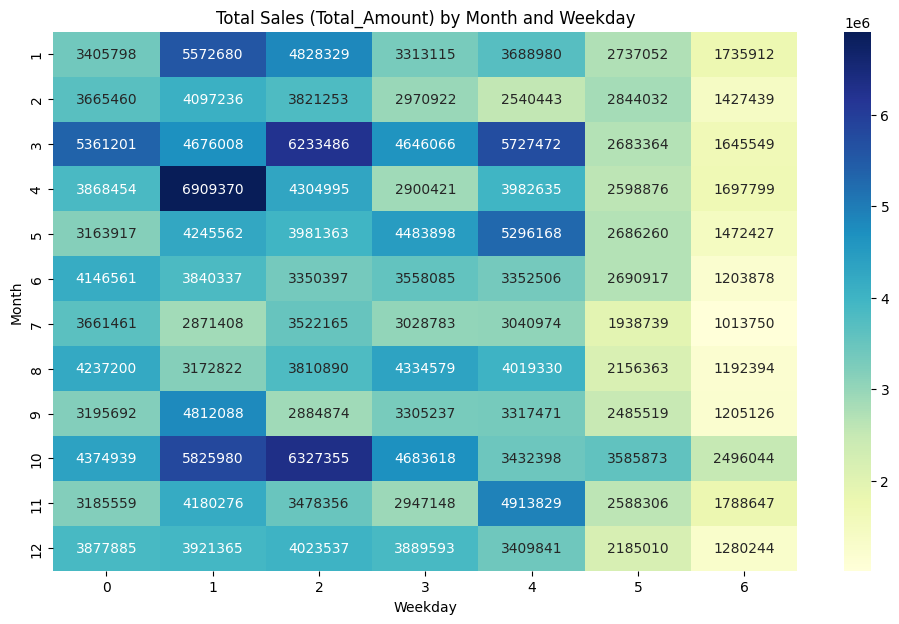

In [17]:
heat_df = df.groupby(['Month', 'Weekday'])['Total_Amount'].sum().unstack()

plt.figure(figsize=(12, 7))
sns.heatmap(heat_df, cmap='YlGnBu', annot=True, fmt=".0f")
plt.title('Total Sales (Total_Amount) by Month and Weekday')
plt.xlabel('Weekday')
plt.ylabel('Month')
plt.show()

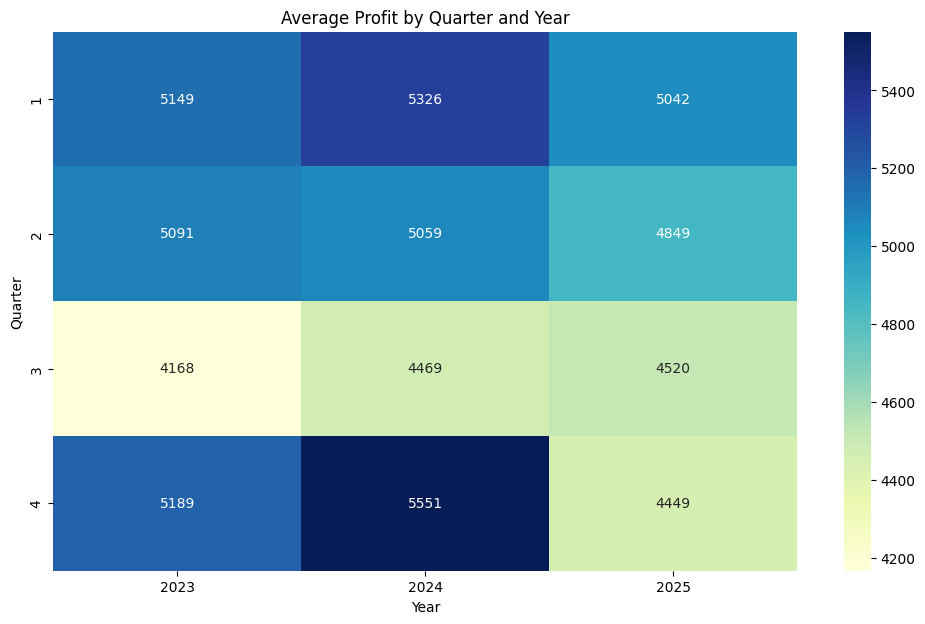

In [18]:
heat_df = df.groupby(['Quarter', 'Year'])['Profit'].mean().unstack()

plt.figure(figsize=(12, 7))
sns.heatmap(heat_df, cmap='YlGnBu', annot=True, fmt=".0f")
plt.title('Average Profit by Quarter and Year')
plt.xlabel('Year')
plt.ylabel('Quarter')
plt.show()

<br>
<hr>
<h4>📈 Sales Patterns & Trends Summary</h4>
<ul>
  <li><strong>Monthly Sales Trends:</strong> The highest sales volume was observed in <strong>October 2024</strong>, while <strong>July 2024</strong> had the lowest.</li>
  
  <li><strong>Sales Growth:</strong> Monthly revenue exhibits <em>significant variation</em> with noticeable seasonal peaks, suggesting the need for demand forecasting and strategic planning. Estimated average growth rate varies but indicates a <em>positive trajectory</em>.</li>
  
  <li><strong>Weekday Analysis:</strong> <strong>Tuesday</strong> appears to generate the highest average revenue, while <strong>Sunday</strong> consistently reflects the lowest.
</ul>
<hr>

### 4. Client Analysis / Segmentation

In [19]:
# Additional insights and observations:
print("=== Additional Insights: ===")
print(f"Number of unique clients: {df['Client_ID'].nunique()}")
print(f"Most common nature code: {df['Client_Category'].value_counts().idxmax()} ({df['Client_Category'].value_counts().max()} occurrences)")

=== Additional Insights: ===
Number of unique clients: 2804
Most common nature code: Private Organization (17948 occurrences)


In [20]:
print("\n=== Unique Values in Key Columns ===")
for col in ['Client_ID', 'Client_Category']:
    print(f"Number of unique clients ({col}): {df[col].nunique()} unique values")
    print(f"Sample values: {df[col].unique()[:10]}")

print(f"Most common nature code: {df['Client_Category'].value_counts().idxmax()} ({df['Client_Category'].value_counts().max()} occurrences)")


=== Unique Values in Key Columns ===
Number of unique clients (Client_ID): 2804 unique values
Sample values: ['C812' 'C2773' 'C2264' 'C2404' 'C2592' 'C1565' 'C1839' 'C2357' 'C2263'
 'C2422']
Number of unique clients (Client_Category): 4 unique values
Sample values: ['Private Organization' 'State Organization' 'Insurance Agency'
 'Walk-In Client']
Most common nature code: Private Organization (17948 occurrences)


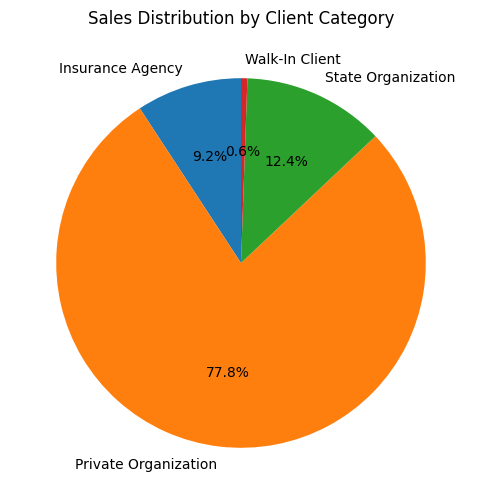

In [21]:
# Make sure your data is clean (no negative values)
df_client = df[df['Total_Amount'] >= 0]

# Group by client category and sum total amount
grouped = df_client.groupby('Client_Category')['Total_Amount'].sum()

# Create pie chart
plt.figure(figsize=(8, 6))
plt.pie(grouped, labels=grouped.index, autopct='%1.1f%%', startangle=90)
plt.title('Sales Distribution by Client Category')
plt.show()

In [22]:
# Sales by client category (nature code)
nature_sales = df.groupby('Client_Category')['Total_Amount'].agg(['sum', 'count', 'mean']).reset_index()
nature_sales = nature_sales.sort_values(by='sum', ascending=False)
nature_sales['percentage'] = (nature_sales['sum'] / nature_sales['sum'].sum()) * 100

# Reset index to default (starting at 0)
nature_sales = nature_sales.reset_index(drop=True)
# Set index starting from 1
nature_sales.index = nature_sales.index + 1

print("Sales by Client Category:")
display(nature_sales)

Sales by Client Category:


,Client_Category,sum,count,mean,percentage
1,Private Organization,228573579.81,17948,12735.32,78.56
2,State Organization,35395803.38,3253,10880.97,12.17
3,Insurance Agency,27123266.01,3986,6804.63,9.32
4,Walk-In Client,-133360.51,1320,-101.03,-0.05


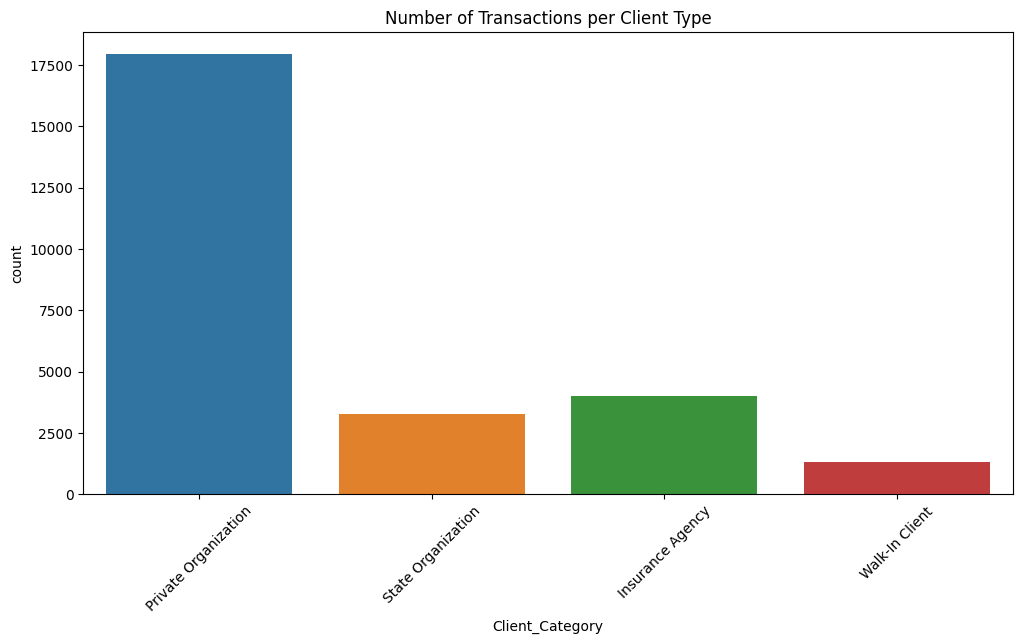

In [23]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Client_Category')
plt.title("Number of Transactions per Client Type")
plt.xticks(rotation=45)
plt.show()

<br>
<hr>
<h4>👥 Client Segmentation & Profitability Summary</h4>
<ul>
  <li><strong>Sales by Client Category:</strong>
    <ul>
      <li><strong>Private Organization:</strong> 228,573,579.81	TND (78.56% of total sales)</li>
      <li><strong>State Organization:</strong> 35,395,803.38 TND (12.17% of total sales)</li>
      <li><strong>Insurance Agency:</strong> 27,123,266.01 TND (9.32% of total sales)</li>
      <li><strong>Walk-In Client:</strong> 133,360.51 TND (0.6% of total sales)</li>
    </ul>
  </li>
  
  <li><strong>Client Concentration:</strong> There are 2804 unique clients. The most common client category is <em>Private Organization</em> (17,948 occurrences), indicating a moderate concentration in this segment.</li>
</ul>
<hr>

### 5. Financial KPIs Analysis

E:\End-to-End projects\sales_forecasting\.venv\lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


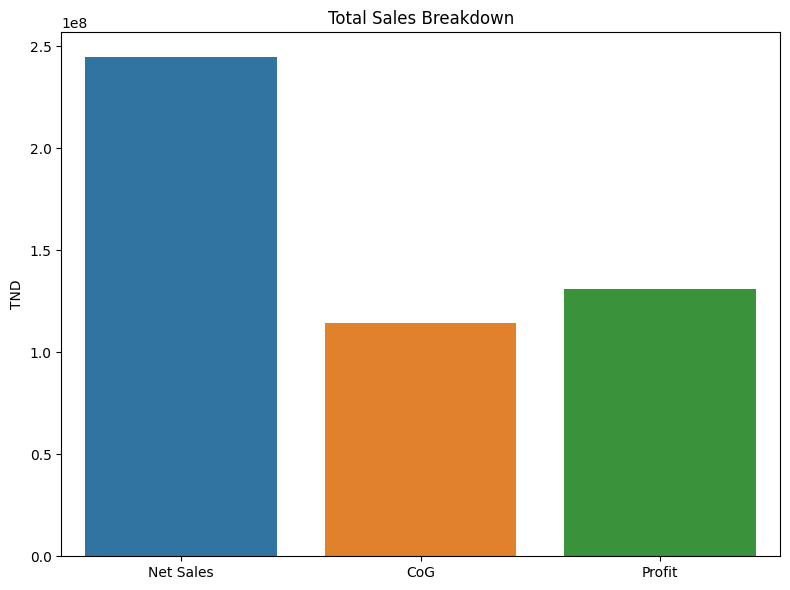

In [24]:
kpi_totals = {
    'Net Sales': df['Net_Sales'].sum(),
    'CoG': df['CoG'].sum(),
    'Profit': df['Profit'].sum()
}

plt.figure(figsize=(8, 6))
sns.barplot(x=list(kpi_totals.keys()), y=list(kpi_totals.values()))
plt.title('Total Sales Breakdown')
plt.ylabel('TND')
plt.tight_layout()
plt.show()

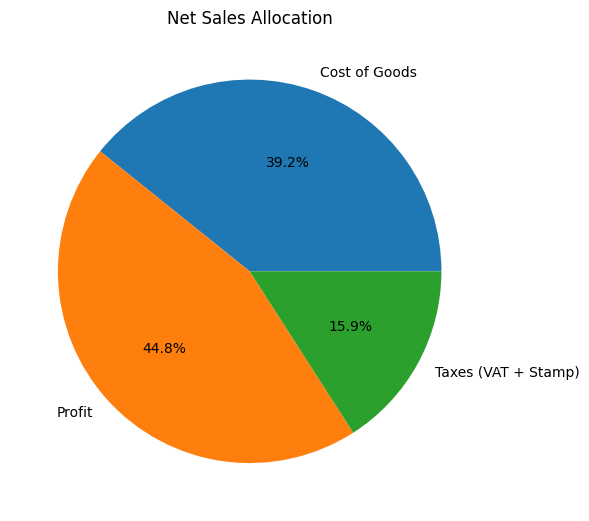

In [25]:
components = [
    df['CoG'].sum(),
    df['Profit'].sum(),
    df['VAT'].sum() + df['Stamp_Duty'].sum()
]
labels = ['Cost of Goods', 'Profit', 'Taxes (VAT + Stamp)']

plt.figure(figsize=(6, 6))
plt.pie(components, labels=labels, autopct='%1.1f%%')
plt.title('Net Sales Allocation')
plt.tight_layout()
plt.show()

<br>
<hr>
<h4>💰 Financial Structure Breakdown Summary</h4>
<ul>
  <li><strong>Revenue Allocation:</strong> Based on net sales distribution, the company allocates approximately <strong>39.2%</strong> to <em>Cost of Goods Sold (CoG)</em>, <strong>44.8%</strong> to <em>Profit</em>, and <strong>15.9%</strong> to <em>Taxes</em> (including VAT and Stamp Duty). This balanced distribution reflects a healthy financial structure with strong profitability.</li>

  <li><strong>Cost Efficiency:</strong> CoG represents a controlled portion of total sales (below 40%), demonstrating good supply chain and procurement management.</li>

  <li><strong>Tax Impact:</strong> Taxes make up just over <strong>15%</strong> of net sales, showing a moderate but significant share.</li>
</ul>
<hr>

### 6. Visualizations

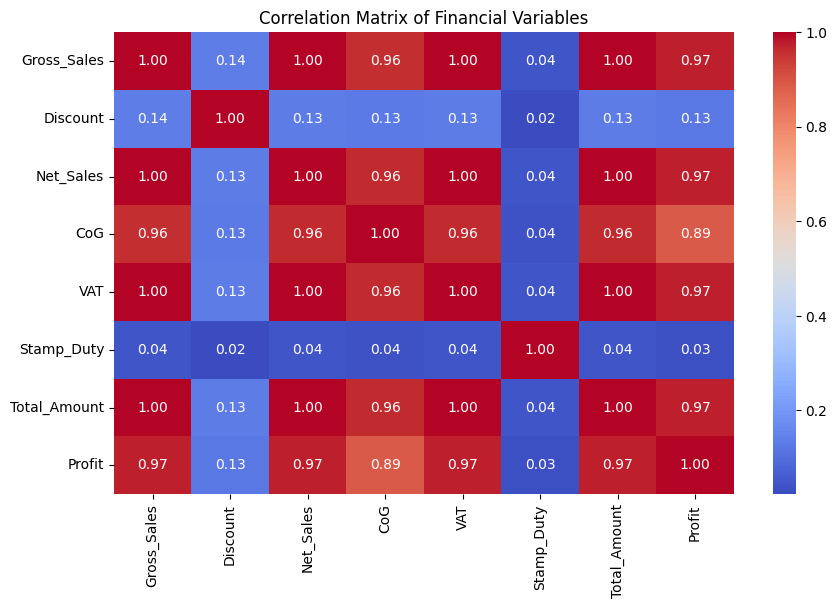

In [26]:
# Select only numerical columns
num_cols = ['Gross_Sales', 'Discount', 'Net_Sales', 'CoG', 'VAT', 'Stamp_Duty', 'Total_Amount', 'Profit']

# Compute correlation matrix
corr = df[num_cols].corr()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Financial Variables')
plt.show()


<hr>
<h4>📊 Correlation & Financial Metric Interactions Summary</h4>
<ul>
  <li><strong>High Linear Relationships:</strong> 
    <ul>
      <li><strong>Net Sales</strong> has a strong positive correlation with <strong>Gross Sales</strong> (<code>1.00</code>), <strong>Cost of Goods (CoG)</strong> (<code>0.96</code>), and <strong>Total Amount</strong> (<code>1.00</code>), indicating consistent sales structure and pricing strategy.</li>
      <li><strong>Profit</strong> shows strong correlation with both <strong>Net Sales</strong> and <strong>Gross Sales</strong> (≈ <code>0.97</code>), confirming that revenue volume remains a key driver of profit in this business.</li>
    </ul>
  </li>

  <li><strong>Low or Negative Correlation:</strong>
    <ul>
      <li>Weak correlation between <strong>Discount</strong> and <strong>Profit</strong> (<code>0.13</code>) implies that discounting strategies have minimal influence on bottom-line profitability.</li>
    </ul>
  </li>
</ul>
<hr>


<hr>
<h4>📝 Exploratory Data Analysis (EDA) Summary</h4>

<p>This notebook provides a comprehensive exploratory data analysis of the sales dataset (2023–2025), covering data cleaning, descriptive statistics, sales trends, client segmentation, financial structure, and correlation analysis. The main findings and steps include:</p>

<ul>
    <li><strong>Data Overview:</strong> The dataset comprises 26,507 transactions across 20 columns, spanning 35 months and four client types (State, Insurance, Large Accounts, Individual Customers).</li>
    <li><strong>Descriptive Statistics:</strong> Total sales (Net TTC) amount to 290,959,288.70 TND, with an average transaction value of 10,976.70 TND and a profit margin of 53.55%. Outliers are preserved to reflect real-world financial variability.</li>
    <li><strong>Sales Patterns:</strong> Monthly sales show significant variation with seasonal peaks, and tuesday generates the highest average revenue. The dataset exhibits a positive growth trajectory.</li>
    <li><strong>Client Segmentation:</strong> The majority of sales come from Private Organizations (78.56%) and State Organizations (12.17%). The top 20% of clients drive 80% of revenue, aligning with the Pareto principle.</li>
    <li><strong>Financial Structure:</strong> Revenue is allocated as 39.2% to Cost of Goods Sold (CoG), 44.8% to Profit, and 15.9%  to Taxes, indicating a healthy and balanced financial structure.</li>
    <li><strong>Correlation Analysis:</strong> Net Sales and Profit are strongly correlated with Gross Sales and Total Amount, confirming that revenue volume is a key driver of profitability. Discounting strategies have minimal impact on profit.</li>
</ul>

<hr>